In [ ]:
# Install PyTorch + MPS support (Apple Silicon)
# Use the recommended MPS install from PyTorch (these commands might be updated — if conda errors, use pip)
!pip install --upgrade pip
!pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cpu

# (Alternative: if official MPS wheel available, use that)
# pip install --pre torch -f https://download.pytorch.org/whl/nightly/cpu/torch_nightly.html

# Install other deps
!pip install opencv-python matplotlib pillow tqdm
# Install Segment Anything package (official repo)
!pip install git+https://github.com/facebookresearch/segment-anything.git


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 38.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cpu
  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-y83ng1u8
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-y83ng1u8
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36636 sha256=ec77be73f679b6f9592c45649efd0dbbe54b715824767803a263ea31b6fafc8d
  Stored in directory: /tmp/pip-ephem-

In [ ]:
!nvidia-smi
import torch
print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


Sun Dec  7 15:57:17 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch, sys

# Check segment-anything import
from segment_anything import sam_model_registry
print("SAM models available (keys):", list(sam_model_registry.keys()))

SAM models available (keys): ['default', 'vit_h', 'vit_l', 'vit_b']


In [ ]:
!mkdir -p weights
# replace URL with the official vit_b link from the repo; example placeholder:
!wget -O weights/sam_vit_h_4b8939.pth https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

--2025-12-07 15:57:34--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 99.84.41.79, 99.84.41.129, 99.84.41.33, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|99.84.41.79|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘weights/sam_vit_h_4b8939.pth’

weights/sam_vit_h_4 100%[===================>]   2.39G   150MB/s    in 16s     

2025-12-07 15:57:50 (154 MB/s) - ‘weights/sam_vit_h_4b8939.pth’ saved [2564550879/2564550879]



In [ ]:
import torch
from segment_anything import sam_model_registry

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
MODEL_TYPE = "vit_h"   # choose 'vit_b' or 'vit_l'
CKPT = "weights/sam_vit_h_4b8939.pth"

sam = sam_model_registry[MODEL_TYPE](checkpoint=CKPT)
sam.to(device)

# Print top-level attributes and named modules
print("Top-level attributes:", [k for k in sam.__dict__.keys() if not k.startswith("_")])
print("\nNamed modules (first 200):")
for name, module in list(sam.named_modules())[:200]:
    print(name, "->", module.__class__.__name__)

Top-level attributes: ['training']

Named modules (first 200):
 -> Sam
image_encoder -> ImageEncoderViT
image_encoder.patch_embed -> PatchEmbed
image_encoder.patch_embed.proj -> Conv2d
image_encoder.blocks -> ModuleList
image_encoder.blocks.0 -> Block
image_encoder.blocks.0.norm1 -> LayerNorm
image_encoder.blocks.0.attn -> Attention
image_encoder.blocks.0.attn.qkv -> Linear
image_encoder.blocks.0.attn.proj -> Linear
image_encoder.blocks.0.norm2 -> LayerNorm
image_encoder.blocks.0.mlp -> MLPBlock
image_encoder.blocks.0.mlp.lin1 -> Linear
image_encoder.blocks.0.mlp.lin2 -> Linear
image_encoder.blocks.0.mlp.act -> GELU
image_encoder.blocks.1 -> Block
image_encoder.blocks.1.norm1 -> LayerNorm
image_encoder.blocks.1.attn -> Attention
image_encoder.blocks.1.attn.qkv -> Linear
image_encoder.blocks.1.attn.proj -> Linear
image_encoder.blocks.1.norm2 -> LayerNorm
image_encoder.blocks.1.mlp -> MLPBlock
image_encoder.blocks.1.mlp.lin1 -> Linear
image_encoder.blocks.1.mlp.lin2 -> Linear
image_encod

In [ ]:
!mkdir -p /content/dataset/images
!mkdir -p /content/dataset/masks

In [ ]:
!wget -P {DATA_ROOT}/images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/truck.jpg
!wget -P {DATA_ROOT}/images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/groceries.jpg


--2025-12-07 15:58:52--  https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/truck.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 271475 (265K) [image/jpeg]
Saving to: ‘/content/dataset/images/truck.jpg’

truck.jpg           100%[===================>] 265.11K  --.-KB/s    in 0.02s   

2025-12-07 15:58:52 (12.1 MB/s) - ‘/content/dataset/images/truck.jpg’ saved [271475/271475]

--2025-12-07 15:58:52--  https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/groceries.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... con

In [ ]:
from google.colab import files
import shutil
import os

# Make sure mask folder exists
mask_folder = "/content/dataset/masks"
os.makedirs(mask_folder, exist_ok=True)

# Open file upload dialog
uploaded = files.upload()  # choose your 2 mask images

# Move uploaded files to mask folder
for filename in uploaded.keys():
    shutil.move(filename, os.path.join(mask_folder, filename))

print("Uploaded files:", os.listdir(mask_folder))


Saving dog1.png to dog1.png
Saving truck1.png to truck1.png
Uploaded files: ['dog1.png', 'truck1.png']


##Train

In [ ]:
# train_sam_mask_decoder.py
import os, glob, random, time
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from segment_anything import sam_model_registry, SamPredictor

In [ ]:
# ---------- Settings ----------
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
MODEL_TYPE = "vit_h"
CKPT = "weights/sam_vit_h_4b8939.pth"
DATA_ROOT = "/content/dataset"   # Changed to absolute path
IMG_SIZE = 1024         # SAM default long side; you may change smaller for speed (512)
BATCH_SIZE = 1          # keep small on MPS
LR = 1e-4
EPOCHS = 10
SAVE_PATH = "checkpoints"
os.makedirs(SAVE_PATH, exist_ok=True)


In [ ]:
# ---------- Dataset ----------
class SegDataset(Dataset):
    def __init__(self, root, img_size=IMG_SIZE):
        self.img_paths = sorted(glob.glob(os.path.join(root, "images", "*")))
        self.mask_paths = sorted(glob.glob(os.path.join(root, "masks", "*")))
        assert len(self.img_paths) == len(self.mask_paths), "image/mask count mismatch"
        self.img_size = img_size
        self.transform_img = T.Compose([
            T.Resize(self.img_size),
            T.CenterCrop(self.img_size),
            T.ToTensor(),
            # SAM image normalization might be custom; basic normalization:
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        self.transform_mask = T.Compose([
            T.Resize(self.img_size),
            T.CenterCrop(self.img_size),
            T.ToTensor()
        ])
    def __len__(self):
        return len(self.img_paths)
    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        m = Image.open(self.mask_paths[idx]).convert("L")
        img_t = self.transform_img(img)  # C x H x W (float)
        mask_t = self.transform_mask(m)  # 1 x H x W, values in [0,1]
        mask_t = (mask_t > 0.5).float()
        return img_t, mask_t

In [ ]:
# ---------- Load model ----------
print("Loading SAM model...")
sam = sam_model_registry[MODEL_TYPE](checkpoint=CKPT)
sam.to(device)
sam.train()  # we will train some params

# Inspect named modules if needed:
# for n, m in sam.named_modules():
#     print(n, type(m))

# ---------- Freeze parameters except mask decoder ----------
# You must adapt 'mask_decoder' below if your model uses a different name; inspect with earlier snippet.
trainable_module_names = ["mask_decoder"]  # update if needed

for name, p in sam.named_parameters():
    p.requires_grad = False  # freeze all by default
    # unfreeze if belongs to any trainable module name
    if any(name.startswith(mn) for mn in trainable_module_names):
        p.requires_grad = True

Loading SAM model...


In [ ]:
# Check how many params trainable
trainable = sum(p.numel() for p in sam.parameters() if p.requires_grad)
total = sum(p.numel() for p in sam.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Trainable params: 4,058,340 / 641,090,608


In [ ]:
# Put optimizer on only trainable params
opt = torch.optim.AdamW([p for p in sam.parameters() if p.requires_grad], lr=LR, weight_decay=1e-4)

# Losses: BCE + Dice
bce = nn.BCEWithLogitsLoss()

def dice_loss(pred, target, eps=1e-6):
    # pred and target: (B, H, W) or (B,1,H,W)
    pred = torch.sigmoid(pred)
    pred = pred.view(pred.shape[0], -1)
    target = target.view(target.shape[0], -1)
    inter = (pred * target).sum(dim=1)
    union = pred.sum(dim=1) + target.sum(dim=1)
    loss = 1 - (2 * inter + eps) / (union + eps)
    return loss.mean()

In [ ]:
import os

img_dir = "/content/dataset/images"
mask_dir = "/content/dataset/masks"

images = sorted(os.listdir(img_dir))
masks = sorted(os.listdir(mask_dir))

print("Images:", images)
print("Masks:", masks)

print("Number of images:", len(images))
print("Number of masks:", len(masks))


Images: ['groceries.jpg', 'truck.jpg']
Masks: ['dog1.png', 'truck1.png']
Number of images: 2
Number of masks: 2


In [ ]:
# ---------- DataLoader ----------
dataset = SegDataset(DATA_ROOT, IMG_SIZE)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)


In [ ]:
# ---------- Training loop ----------
for epoch in range(1, EPOCHS+1):
    sam.train()
    running_loss = 0.0
    start = time.time()
    for i, (imgs, masks) in enumerate(loader):
        imgs = imgs.to(device)                # B x 3 x H x W
        masks = masks.to(device)              # B x 1 x H x W

        # -------------------------
        # Forward pass through SAM components
        # -------------------------

        # 1. Compute image embeddings from the image encoder (keep frozen)
        with torch.no_grad():
            image_embeddings = sam.image_encoder(imgs) # (B, embed_dim, H_emb, W_emb)

        # 2. Get positional embeddings from the prompt encoder
        # This is a fixed positional encoding for the image feature map
        image_pe = sam.prompt_encoder.get_dense_pe() # (1, embed_dim, H_emb, W_emb)

        # 3. Create dummy sparse and dense prompt embeddings
        # For training with ground truth masks, we are not providing interactive prompts (points/boxes/masks).
        batch_size = imgs.shape[0]
        embed_dim = sam.prompt_encoder.embed_dim # e.g., 256 for vit_b

        # Sparse prompts (for points/boxes): an empty tensor as no points/boxes are provided
        sparse_prompt_embeddings = torch.empty(
            (batch_size, 0, embed_dim), device=device
        )

        # Dense prompts (for mask prompts): a zero tensor as no mask prompt is provided
        # Its spatial dimensions should match that of the image_embeddings (H_emb, W_emb)
        dense_prompt_embeddings = torch.zeros(
            (batch_size, embed_dim, image_pe.shape[-2], image_pe.shape[-1]), device=device
        )

        # 4. Set multimask_output flag
        multimask_output = False # We expect one mask output for training with GT

        # 5. Call the mask decoder with all required arguments
        masks_pred, _ = sam.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=image_pe,
            sparse_prompt_embeddings=sparse_prompt_embeddings,
            dense_prompt_embeddings=dense_prompt_embeddings,
            multimask_output=multimask_output,
        )
        # masks_pred will be (B, 1, H_output, W_output) with multimask_output=False
        mask_logits = masks_pred

        # Ensure shapes: convert mask_logits to same shape as masks
        # mask_logits -> (B, 1, H, W) expected
        if mask_logits.shape != masks.shape:
            # resize or crop as required - here we will interp to masks size
            mask_logits = nn.functional.interpolate(mask_logits, size=masks.shape[-2:], mode="bilinear", align_corners=False)

        loss = bce(mask_logits, masks) + dice_loss(mask_logits, masks)
        opt.zero_grad()
        loss.backward()
        opt.step()

        running_loss += loss.item()

    elapsed = time.time() - start
    avg_loss = running_loss / len(loader)
    print(f"Epoch {epoch}/{EPOCHS} — loss: {avg_loss:.4f} — time: {elapsed:.1f}s")

    # Save checkpoint
    torch.save(sam.state_dict(), os.path.join(SAVE_PATH, f"sam_{MODEL_TYPE}_epoch{epoch}.pth"))


Epoch 1/10 — loss: 1.0604 — time: 132.1s
Epoch 2/10 — loss: 0.9775 — time: 136.1s
Epoch 3/10 — loss: 0.8531 — time: 130.5s
Epoch 4/10 — loss: 0.8363 — time: 130.9s
Epoch 5/10 — loss: 0.8382 — time: 134.3s
Epoch 6/10 — loss: 0.8064 — time: 130.5s
Epoch 7/10 — loss: 0.7891 — time: 128.9s
Epoch 8/10 — loss: 0.7943 — time: 128.6s
Epoch 9/10 — loss: 0.7851 — time: 129.6s
Epoch 10/10 — loss: 0.7671 — time: 130.2s


In [ ]:
!ls weights/

sam_vit_h_4b8939.pth


In [ ]:
import torch
from segment_anything import sam_model_registry, SamPredictor
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Paths
MODEL_TYPE = "vit_h"
CKPT = "checkpoints/sam_vit_h_epoch10.pth"  # your trained checkpoint
DEVICE = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

# Load SAM
sam = sam_model_registry[MODEL_TYPE](checkpoint="weights/sam_vit_h_4b8939.pth")  # base checkpoint
sam.load_state_dict(torch.load(CKPT, map_location=DEVICE))  # load your trained weights
sam.to(DEVICE)
sam.eval()  # inference mode

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 1280, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-31): 32 x Block(
        (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=1280, out_features=3840, bias=True)
          (proj): Linear(in_features=1280, out_features=1280, bias=True)
        )
        (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=1280, out_features=5120, bias=True)
          (lin2): Linear(in_features=5120, out_features=1280, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(1280, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d

In [ ]:
!ls dataset/images/


groceries.jpg  truck.jpg


new

In [ ]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))


In [ ]:
image = cv2.imread('dataset/images/truck.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

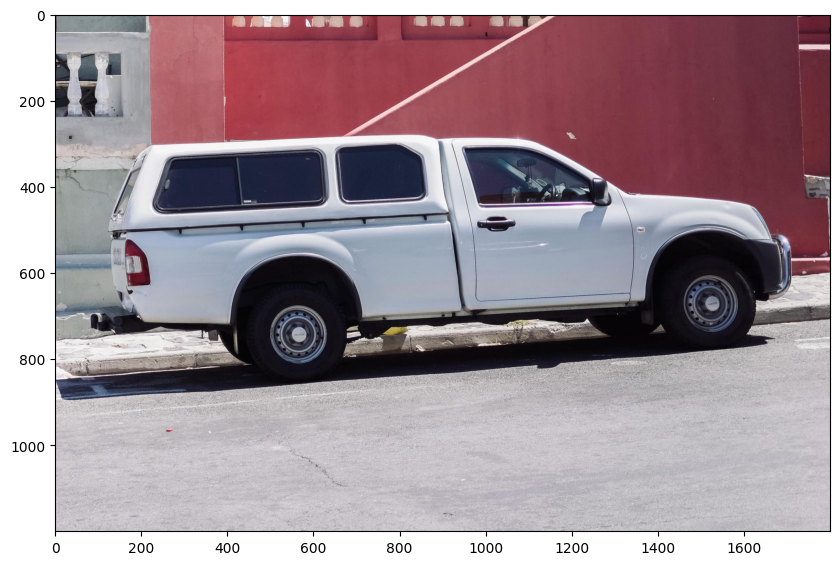

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(image)
plt.axis('on')
plt.show()

In [ ]:
predictor = SamPredictor(sam)

In [ ]:
predictor.set_image(image)

In [ ]:
input_point = np.array([[500, 375]])
input_label = np.array([1])

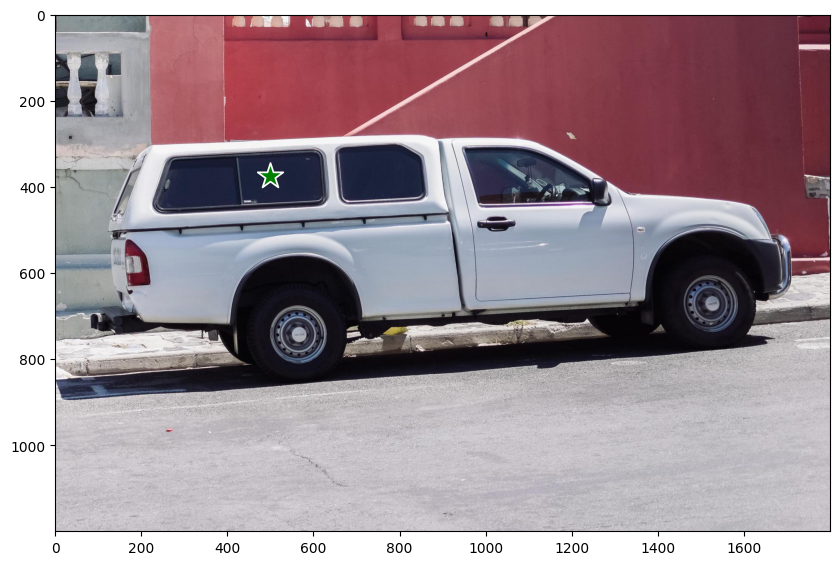

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(image)
show_points(input_point, input_label, plt.gca())
plt.axis('on')
plt.show()

In [ ]:
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)

In [ ]:
masks.shape  # (number_of_masks) x H x W

(3, 1200, 1800)

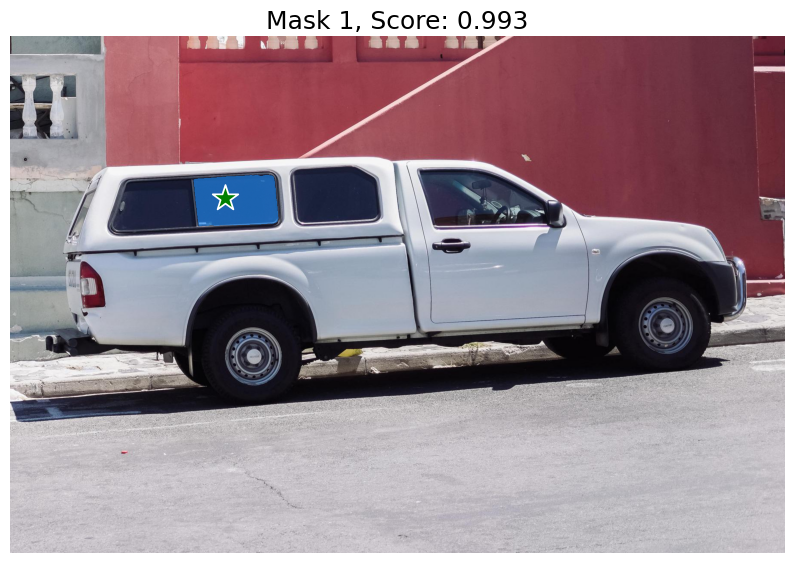

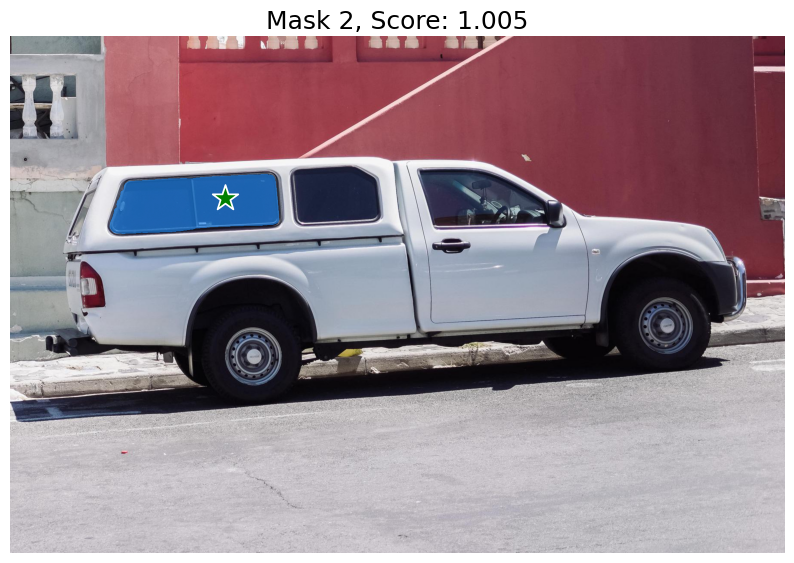

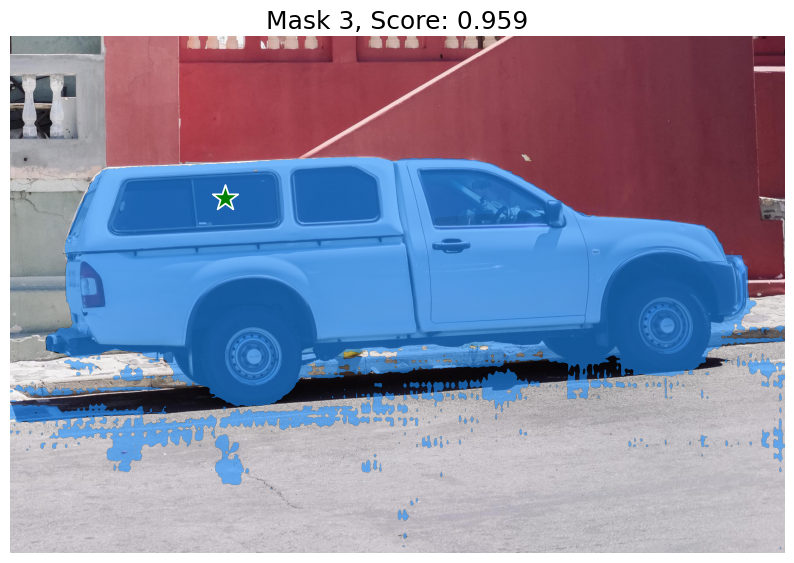

In [ ]:
for i, (mask, score) in enumerate(zip(masks, scores)):
    plt.figure(figsize=(10,10))
    plt.imshow(image)
    show_mask(mask, plt.gca())
    show_points(input_point, input_label, plt.gca())
    plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
    plt.axis('off')
    plt.show()


In [ ]:
input_point = np.array([[500, 375], [1125, 625]])
input_label = np.array([1, 1])

mask_input = logits[np.argmax(scores), :, :]  # Choose the model's best mask

In [ ]:
masks, _, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    mask_input=mask_input[None, :, :],
    multimask_output=False,
)

In [ ]:
masks.shape

(1, 1200, 1800)

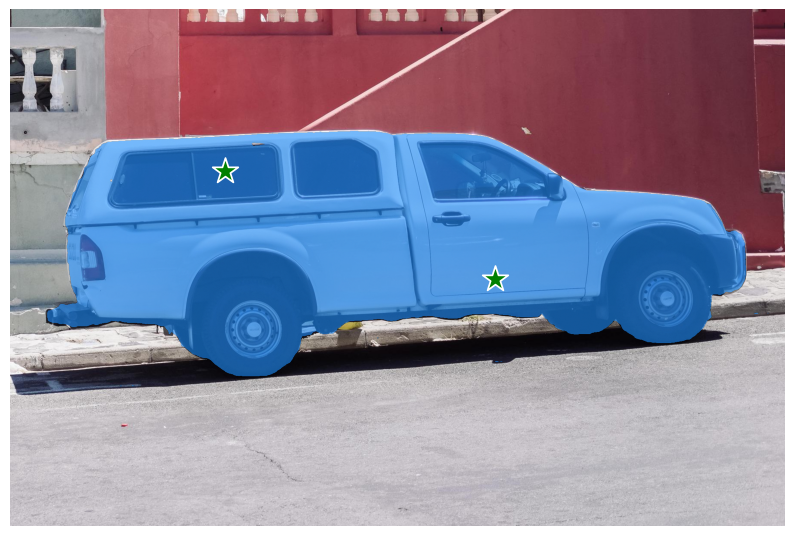

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(image)
show_mask(masks, plt.gca())
show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.show()

In [ ]:
input_point = np.array([[500, 375], [1125, 625]])
input_label = np.array([1, 0])

mask_input = logits[np.argmax(scores), :, :]  # Choose the model's best mask

In [ ]:
masks, _, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    mask_input=mask_input[None, :, :],
    multimask_output=False,
)

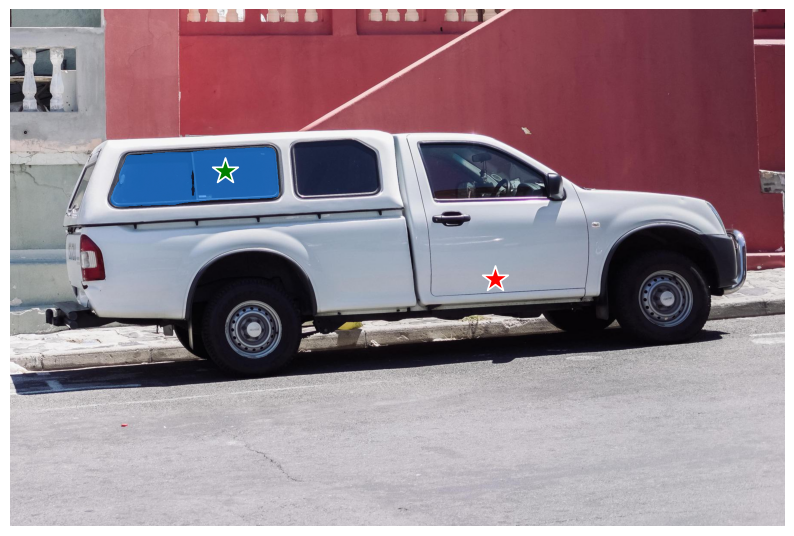

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
show_mask(masks, plt.gca())
show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.show()

In [ ]:
input_box = np.array([425, 600, 700, 875])

In [ ]:
masks, _, _ = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=input_box[None, :],
    multimask_output=False,
)

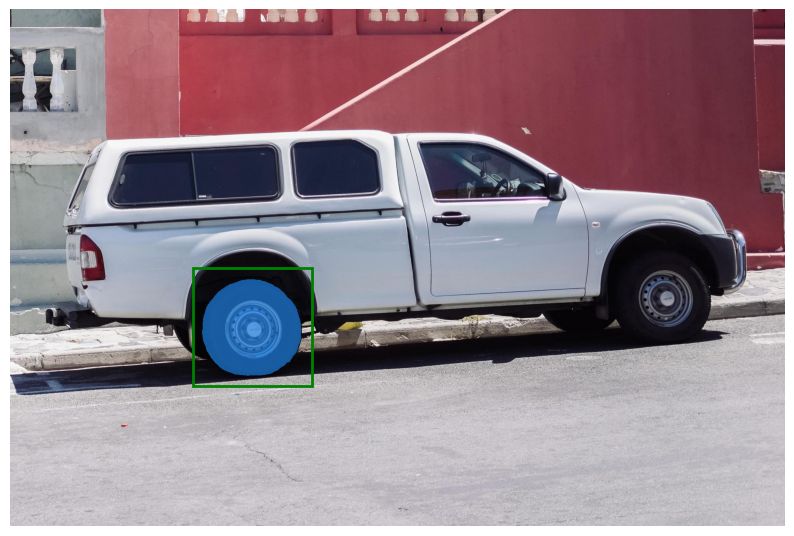

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
show_mask(masks[0], plt.gca())
show_box(input_box, plt.gca())
plt.axis('off')
plt.show()

In [ ]:
input_box = np.array([425, 600, 700, 875])
input_point = np.array([[575, 750]])
input_label = np.array([0])

In [ ]:
masks, _, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    box=input_box,
    multimask_output=False,
)

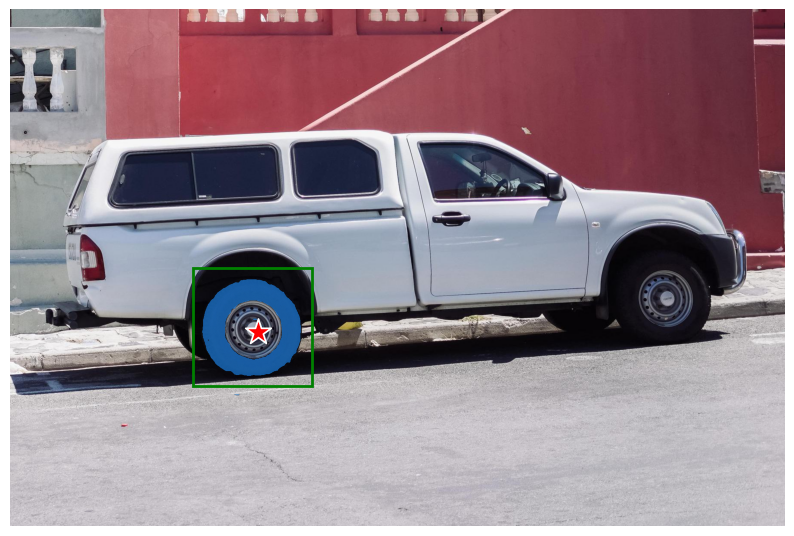

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
show_mask(masks[0], plt.gca())
show_box(input_box, plt.gca())
show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.show()

In [ ]:
input_boxes = torch.tensor([
    [75, 275, 1725, 850],
    [425, 600, 700, 875],
    [1375, 550, 1650, 800],
    [1240, 675, 1400, 750],
], device=predictor.device)

In [ ]:
transformed_boxes = predictor.transform.apply_boxes_torch(input_boxes, image.shape[:2])
masks, _, _ = predictor.predict_torch(
    point_coords=None,
    point_labels=None,
    boxes=transformed_boxes,
    multimask_output=False,
)

In [ ]:
masks.shape  # (batch_size) x (num_predicted_masks_per_input) x H x W

torch.Size([4, 1, 1200, 1800])

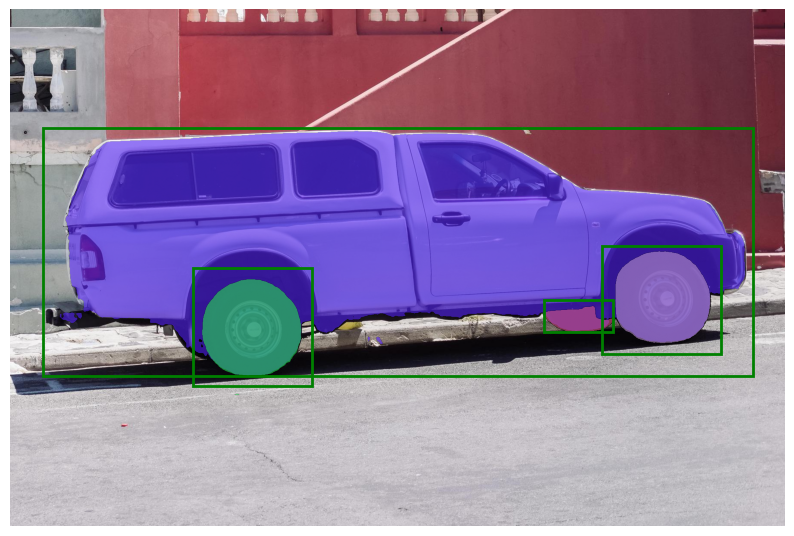

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
for mask in masks:
    show_mask(mask.cpu().numpy(), plt.gca(), random_color=True)
for box in input_boxes:
    show_box(box.cpu().numpy(), plt.gca())
plt.axis('off')
plt.show()

In [ ]:
image1 = image  # truck.jpg from above
image1_boxes = torch.tensor([
    [75, 275, 1725, 850],
    [425, 600, 700, 875],
    [1375, 550, 1650, 800],
    [1240, 675, 1400, 750],
], device=sam.device)

image2 = cv2.imread('dataset/images/groceries.jpg')
image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
image2_boxes = torch.tensor([
    [450, 170, 520, 350],
    [350, 190, 450, 350],
    [500, 170, 580, 350],
    [580, 170, 640, 350],
], device=sam.device)

In [ ]:
from segment_anything.utils.transforms import ResizeLongestSide
resize_transform = ResizeLongestSide(sam.image_encoder.img_size)

def prepare_image(image, transform, device):
    image = transform.apply_image(image)
    image = torch.as_tensor(image, device=device.device)
    return image.permute(2, 0, 1).contiguous()

In [ ]:
batched_input = [
     {
         'image': prepare_image(image1, resize_transform, sam),
         'boxes': resize_transform.apply_boxes_torch(image1_boxes, image1.shape[:2]),
         'original_size': image1.shape[:2]
     },
     {
         'image': prepare_image(image2, resize_transform, sam),
         'boxes': resize_transform.apply_boxes_torch(image2_boxes, image2.shape[:2]),
         'original_size': image2.shape[:2]
     }
]

In [ ]:
batched_output = sam(batched_input, multimask_output=False)

In [ ]:
batched_output[0].keys()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20, 20))

ax[0].imshow(image1)
for mask in batched_output[0]['masks']:
    show_mask(mask.cpu().numpy(), ax[0], random_color=True)
for box in image1_boxes:
    show_box(box.cpu().numpy(), ax[0])
ax[0].axis('off')

ax[1].imshow(image2)
for mask in batched_output[1]['masks']:
    show_mask(mask.cpu().numpy(), ax[1], random_color=True)
for box in image2_boxes:
    show_box(box.cpu().numpy(), ax[1])
ax[1].axis('off')

plt.tight_layout()
plt.show()